In [1]:
from ravex import MultiPlanetSystem
import numpy as np
import astropy.units as u
import astropy.time as t
import matplotlib.pyplot as plt

In [2]:
# Define the host star mass
mass_star = 0.62 * u.solMass

# Define a single planet
planet1 = {
    "mass": 3.575 * u.earthMass,
    "time_periastron": t.Time("2019-11-30T04:23:05.000", format="isot", scale="utc"),
    "inclination": 90.0 * u.deg,
    "argument_periapse": 90.0 * u.deg,
    "eccentricity": 0.0,
    "orbital_period": 13.47 * u.day,
}

# Build the planetary system
system = MultiPlanetSystem(mass_star, [planet1])

In [3]:
# Build a dense and regular time grid to sample the theoretical RV curve
n_model = 10000
span_days = 2 * planet1["orbital_period"].to_value(u.day)
start_time = t.Time("2020-01-01T00:00:00", format="isot", scale="utc")

time_grid = t.Time(
    start_time.jd + np.linspace(0, span_days, n_model),
    format="jd",
    scale="utc"
)

# Compute the noiseless RV model
jd_model, rv_model, phases_model, phased_model = system.get_rvs(time_grid)

In [4]:
rv_max = np.max(rv_model)
rv_min = np.min(rv_model)
K_est = 0.5 * (rv_max - rv_min)

print(f"Estimated semi-amplitude K: {K_est:.3f} m/s")

Estimated semi-amplitude K: 1.321 m/s


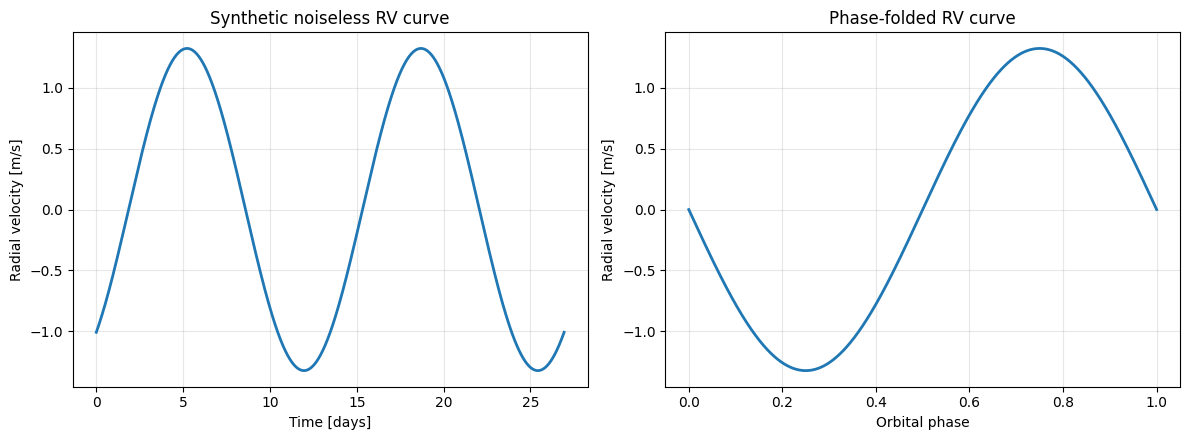

In [5]:
# Plot the theoretical noiseless RV curve in time and phase
time_days = jd_model - jd_model[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left panel: RV as a function of time
axes[0].plot(time_days, rv_model, lw=2)
axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel("Radial velocity [m/s]")
axes[0].set_title("Synthetic noiseless RV curve")
axes[0].grid(alpha=0.3)

# Right panel: RV as a function of orbital phase
axes[1].plot(phased_model["p0"]["phase"], phased_model["p0"]["rv"], lw=2)
axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("Radial velocity [m/s]")
axes[1].set_title("Phase-folded RV curve")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
